# Israeli Real Estate Data - Initial EDL, Profiling, Cleaning, and Exploration
Ehud Vaknin 209479088 and Moshe Bercovich 206676850

This notebook documents the first stages of the project:

1. Loading raw data from two public-source collections
2. Inspecting the schema and raw payload structure
3. Applying common EDL techniques:
   - source profiling
   - schema discovery
   - type inference
   - missing-value analysis
   - duplicate detection
   - domain validation
   - canonical field mapping
4. Cleaning and standardizing the transaction data
5. Building a first normalized analytical dataset
6. Performing exploratory data analysis (EDA)
7. Preparing the data for later feature engineering and modeling

The raw data currently comes from two different source families:

- OData real-estate transaction records
- CBS housing market index records

These sources have different granularity:
- OData = transaction-level data
- CBS = quarterly macro indicator data

Therefore, raw storage and normalized analytical representation must be separated.

## 1. Environment setup

We begin by importing the libraries used for:
- JSON parsing
- tabular manipulation
- visualization
- basic data quality checks
- optional geospatial inspection

This notebook is designed to work first from local JSON exports (250 records in each sample).

In [ ]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
DATA_DIR = Path("/content")

odata_path = DATA_DIR / "israel_housing.raw_records_odata_il_nadlan.json"
cbs_path = DATA_DIR / "israel_housing.raw_records._cbs_housing.json"

with open(odata_path, "r", encoding="utf-8") as f:
    odata_raw = json.load(f)

with open(cbs_path, "r", encoding="utf-8") as f:
    cbs_raw = json.load(f)

print(f"OData raw records: {len(odata_raw):,}")
print(f"CBS raw records:   {len(cbs_raw):,}")

OData raw records: 250
CBS raw records:   250


## 2. Inspect the raw document envelope

Both sources appear to use a common ingestion envelope with fields such as:
- `source_name`
- `source_url`
- `ingested_at`
- `retrieval_method`
- `raw_payload`
- `parsing_status`
- `content_hash`
- `schema_version`
- `job_id`


In [ ]:
print("OData envelope keys:")
print(list(odata_raw[0].keys()))

print("\nCBS envelope keys:")
print(list(cbs_raw[0].keys()))

OData envelope keys:
['_id', 'source_name', 'source_url', 'ingested_at', 'retrieval_method', 'raw_payload', 'parsing_status', 'content_hash', 'schema_version', 'tags', 'job_id', 'geometry']

CBS envelope keys:
['_id', 'source_name', 'source_url', 'ingested_at', 'retrieval_method', 'raw_payload', 'parsing_status', 'content_hash', 'schema_version', 'tags', 'job_id']


odata sample :

In [ ]:
odata_raw[0]

{'_id': {'$oid': '69b1da940fa99efc3c3a0a7a'},
 'source_name': 'odata_il_nadlan',
 'source_url': 'https://www.odata.org.il/dataset/84f2bc2d-87a0-474e-a3ea-63d7bb9b5447/resource/5eb859da-6236-4b67-bcd1-ec4b90875739/download/.zip',
 'ingested_at': {'$date': '2026-03-11T21:10:42.445Z'},
 'retrieval_method': 'zip_download',
 'raw_payload': {'transaction_date': '21.01.2020',
  'transaction_datetime': '2020-01-21T00:00:00',
  'full_address': 'כרמל 7, רחובות',
  'display_address': 'כרמל 7',
  'block': '5908-67-307',
  'property_type': 'דירה בבית קומות',
  'rooms': '4',
  'floor': 'שלוש עשרה',
  'DEALNATURE': '92',
  'price': '2,050,000',
  'new_project_text': None,
  'project_name': None,
  'building_year': '2009',
  'year_built': None,
  'building_floors': '27',
  'key_value': '10082725464',
  'type': 1,
  'polygon_id': '5908-67',
  'trend_is_negative': False,
  'trend_format': None,
  'city': 'רחובות',
  'street': 'כרמל'},
 'parsing_status': 'raw',
 'content_hash': '54e496d9490e45c9d35891646

cbs sample :

In [ ]:
cbs_raw[0]

{'_id': {'$oid': '69b2174253f3cdf16c2d5a3e'},
 'source_name': 'cbs_housing',
 'source_url': 'https://api.cbs.gov.il/index/data/price',
 'ingested_at': {'$date': '2026-03-12T01:30:42.627Z'},
 'retrieval_method': 'http_get',
 'raw_payload': {'series_code': 40010,
  'series_name': 'מחירי דירות',
  'period_type': 'quarter',
  'year': 1989,
  'percent_change': 10.4,
  'percent_change_annual': 35.9,
  'current_base': 168.4,
  'base_description': '1987 ממוצע',
  'previous_base': None,
  'source': 'cbs',
  'quarter': 3,
  'quarterDesc': 'יולי-ספטמבר'},
 'parsing_status': 'raw',
 'content_hash': '9bc112160881548f0b69366a5f867e9b1e76e4f54cb91486670d6af9711a87a6',
 'schema_version': 'v1',
 'tags': [],
 'job_id': '69b2173d53f3cdf16c2d58ad'}

## 3. Flatten the raw payloads

For data analysis, we usually create two tables:

1. an envelope table for ingestion metadata
2. a flattened payload table for actual analysis

For this notebook, we flatten `raw_payload` into top-level columns and keep selected metadata columns.

In [ ]:
def flatten_raw_records(records):
    rows = []
    for rec in records:
        row = {
            "_id": rec.get("_id", {}).get("$oid") if isinstance(rec.get("_id"), dict) else rec.get("_id"),
            "source_name": rec.get("source_name"),
            "source_url": rec.get("source_url"),
            "ingested_at": rec.get("ingested_at", {}).get("$date") if isinstance(rec.get("ingested_at"), dict) else rec.get("ingested_at"),
            "retrieval_method": rec.get("retrieval_method"),
            "parsing_status": rec.get("parsing_status"),
            "content_hash": rec.get("content_hash"),
            "schema_version": rec.get("schema_version"),
            "job_id": rec.get("job_id"),
        }

        payload = rec.get("raw_payload", {})
        for k, v in payload.items():
            row[k] = v

        geometry = rec.get("geometry")
        if isinstance(geometry, dict):
            coords = geometry.get("coordinates", [None, None])
            row["geometry_type"] = geometry.get("type")
            row["longitude"] = coords[0] if len(coords) > 0 else None
            row["latitude"] = coords[1] if len(coords) > 1 else None

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
df_odata = flatten_raw_records(odata_raw)
df_odata.head(3)

,_id,source_name,source_url,ingested_at,retrieval_method,parsing_status,content_hash,schema_version,job_id,transaction_date,...,key_value,type,polygon_id,trend_is_negative,trend_format,city,street,geometry_type,longitude,latitude
0,69b1da940fa99efc3c3a0a7a,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,54e496d9490e45c9d358916464813d86bd64067e2c96f7...,v1,69b1da0d0fa99efc3c36737a,21.01.2020,...,10082725464,1,5908-67,False,None,רחובות,כרמל,Point,34.822027,31.906504
1,69b1da940fa99efc3c3a0a79,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,1a1fef7022f9e47a1b71105e299915aa50541aeec2ecb5...,v1,69b1da0d0fa99efc3c36737a,21.01.2020,...,10082413572,1,5908-53,False,125% ב 12.7 שנים,רחובות,כרמל,Point,34.821559,31.905816
2,69b1da940fa99efc3c3a0a8b,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,b8f917e82bf9f0526636d08e3a860926388226f5aec568...,v1,69b1da0d0fa99efc3c36737a,21.08.2020,...,10099719840,1,5908-65,False,88% ב 12.8 שנים,רחובות,כרמל,Point,34.820953,31.906285


In [ ]:
df_cbs = flatten_raw_records(cbs_raw)
df_cbs.head(5)

,_id,source_name,source_url,ingested_at,retrieval_method,parsing_status,content_hash,schema_version,job_id,series_code,...,percent_change,percent_change_annual,current_base,base_description,previous_base,source,quarter,quarterDesc,month,month_name_he
0,69b2174253f3cdf16c2d5a3e,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,9bc112160881548f0b69366a5f867e9b1e76e4f54cb914...,v1,69b2173d53f3cdf16c2d58ad,40010,...,10.4,35.9,168.4,1987 ממוצע,None,cbs,3.0,יולי-ספטמבר,NaN,NaN
1,69b2174253f3cdf16c2d5a44,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,77e6151c949af88ef794639ba7dd13d04f7c969ba5150d...,v1,69b2173d53f3cdf16c2d58ad,40010,...,4.9,13.9,109.1,1987 ממוצע,None,cbs,1.0,ינואר-מרס,NaN,NaN
2,69b2174253f3cdf16c2d5a4b,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,325853e1b11c8887bb4f81c99a4536d7449c445c7b55a5...,v1,69b2173d53f3cdf16c2d58ad,40010,...,2.4,37.6,126.2,1985 ממוצע,None,cbs,2.0,אפריל-יוני,NaN,NaN
3,69b2174253f3cdf16c2d5a30,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,99db09cd4bbf0726651b80d4610f9f8a52f10eae66cfde...,v1,69b2173d53f3cdf16c2d58ad,40010,...,8.1,22.5,355.4,1987 ממוצע,None,cbs,1.0,ינואר-מרס,NaN,NaN
4,69b2174253f3cdf16c2d5a42,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,66ffdeccbc367e90caf30bec5cbd8214c2ca16e704c9a1...,v1,69b2173d53f3cdf16c2d58ad,40010,...,9.3,21.9,123.9,1987 ממוצע,None,cbs,3.0,יולי-ספטמבר,NaN,NaN


## 4. Schema discovery and profiling

This step is **schema profiling**:
- identify columns
- inspect types
- estimate cardinality
- check missingness
- review sample values

This helps reveal schema drift, mixed types, and candidate cleaning rules.

In [ ]:
def profile_dataframe(df):
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_count": [df[c].notna().sum() for c in df.columns],
        "null_count": [df[c].isna().sum() for c in df.columns],
        "null_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
        "sample_values": [list(df[c].dropna().astype(str).head(3).values) for c in df.columns],
    })
    return summary.sort_values(["null_pct", "n_unique"], ascending=[False, True])

In [ ]:
odata_profile = profile_dataframe(df_odata)
odata_profile.head(10)

,column,dtype,non_null_count,null_count,null_pct,n_unique,sample_values
22,year_built,object,3,247,98.8,2,"[2011, 2008, 2011]"
19,new_project_text,object,7,243,97.2,1,"[1, 1, 1]"
20,project_name,object,7,243,97.2,1,"[המגדל הנשיאותי, המגדל הנשיאותי, המגדל הנשיאותי]"
28,trend_format,object,92,158,63.2,92,"[125% ב 12.7 שנים, 88% ב 12.8 שנים, 49% ב 10.1..."
14,property_type,object,232,18,7.2,6,"[דירה בבית קומות, דירה בבית קומות, דירה בבית ק..."
23,building_floors,object,246,4,1.6,11,"[27, 4, 27]"
15,rooms,object,247,3,1.2,9,"[4, 4, 4]"
16,floor,object,247,3,1.2,30,"[שלוש עשרה, שניה, ארבע עשרה]"
1,source_name,object,250,0,0.0,1,"[odata_il_nadlan, odata_il_nadlan, odata_il_na..."
2,source_url,object,250,0,0.0,1,[https://www.odata.org.il/dataset/84f2bc2d-87a...


In [ ]:
cbs_profile = profile_dataframe(df_cbs)
cbs_profile.head(10)

,column,dtype,non_null_count,null_count,null_pct,n_unique,sample_values
17,previous_base,object,0,250,100.0,0,[]
19,quarter,float64,41,209,83.6,4,"[3.0, 1.0, 2.0]"
20,quarterDesc,object,41,209,83.6,4,"[יולי-ספטמבר, ינואר-מרס, אפריל-יוני]"
21,month,float64,209,41,16.4,12,"[8.0, 10.0, 5.0]"
22,month_name_he,object,209,41,16.4,12,"[אוגוסט, אוקטובר, מאי]"
14,percent_change_annual,float64,225,25,10.0,180,"[35.9, 13.9, 37.6]"
1,source_name,object,250,0,0.0,1,"[cbs_housing, cbs_housing, cbs_housing]"
2,source_url,object,250,0,0.0,1,"[https://api.cbs.gov.il/index/data/price, http..."
4,retrieval_method,object,250,0,0.0,1,"[http_get, http_get, http_get]"
5,parsing_status,object,250,0,0.0,1,"[raw, raw, raw]"


## 5. Initial data-quality observations

From the source samples, several common issues found:

### OData transactions

The initial profiling suggests the following:

- several fields are stored as `object` and should be type-normalized during preprocessing, especially:
  - `rooms`
  - `building_floors`
  - likely also `price`, `building_year`, and date fields if they were loaded as strings in the raw source
- `floor` values appear as Hebrew text, for example:
  - `שלוש עשרה`
  - `שניה`
  - `ארבע עשרה`
  so a mapping step to numeric floor values is needed
- some fields are highly sparse and should be treated as optional at this stage:
  - `year_built` — almost entirely missing
  - `new_project_text` — mostly missing
  - `project_name` — mostly missing
  - `trend_format` — partially populated
- `property_type` has low missingness and looks usable as an important categorical feature
- `rooms`, `floor`, and `building_floors` are nearly complete and are strong candidates for early analysis and feature engineering
- overlapping semantics still exist and should be resolved in the normalized layer:
  - `transaction_date` vs `transaction_datetime`
  - `building_year` vs `year_built`
- geolocation is available and can support spatial enrichment through coordinates extracted from `geometry.coordinates`

###

### CBS housing index

The initial profiling suggests the following:

- the CBS dataset is generally more structured than the transaction dataset, with several core fields already parsed as numeric, such as:
  - `quarter`
  - `month`
  - `percent_change_annual`
- the time structure appears to be mixed:
  - some records are represented at the **quarter** level
  - others include **month** and `month_name_he`
  this means the source may contain more than one temporal representation, so `period_type` should be used carefully during normalization
- `quarter` and `quarterDesc` are highly sparse, each populated in only a small subset of records
- `month` and `month_name_he` are much more complete and seem to describe the dominant temporal granularity in the current sample
- `previous_base` is entirely missing in this sample and should currently be treated as an unavailable optional field rather than a reliable analytical feature
- `percent_change_annual` is mostly populated and appears suitable for time-series exploration and enrichment
- metadata fields such as:
  - `source_name`
  - `source_url`
  - `retrieval_method`
  - `parsing_status`
  are complete across all records and support lineage and ingestion traceability
- Hebrew descriptive fields such as `quarterDesc` and `month_name_he` should be preserved in the raw layer, while normalized analytical fields should rely on numeric time components where possible

In [ ]:
def inspect_column(df, col, top_n=10):
    print(f"Column: {col}")
    print("-" * 50)
    print("dtype:", df[col].dtype)
    print("nulls:", df[col].isna().sum())
    print("n_unique:", df[col].nunique(dropna=True))
    print("\nTop values:")
    print(df[col].value_counts(dropna=False).head(top_n))
    print("\nSample:")
    display(df[[col]].head(10))

In [ ]:
inspect_column(df_odata, "property_type")

Column: property_type
--------------------------------------------------
dtype: object
nulls: 18
n_unique: 6

Top values:
property_type
דירה בבית קומות    220
None                18
קוטג' דו משפחתי      5
דירה                 2
קרקע למגורים         2
דירת גג              2
ללא תיכנון           1
Name: count, dtype: int64

Sample:


,property_type
0,דירה בבית קומות
1,דירה בבית קומות
2,דירה בבית קומות
3,דירה בבית קומות
4,דירה בבית קומות
5,דירה בבית קומות
6,דירה בבית קומות
7,דירה בבית קומות
8,ללא תיכנון
9,קוטג' דו משפחתי


In [ ]:
inspect_column(df_odata, "floor")

Column: floor
--------------------------------------------------
dtype: object
nulls: 3
n_unique: 30

Top values:
floor
שלישית       33
רביעית       30
שניה         27
ראשונה       27
שביעית       12
חמישית       11
שישית        11
תשיעית        9
שלוש עשרה     9
שמינית        9
Name: count, dtype: int64

Sample:


,floor
0,שלוש עשרה
1,שניה
2,ארבע עשרה
3,חמישית
4,שניה
5,שניה
6,אחת עשרה
7,אחת עשרה
8,None
9,"מרתף, קרקע, ראשונה"


In [ ]:
inspect_column(df_odata, "price")

Column: price
--------------------------------------------------
dtype: object
nulls: 0
n_unique: 184

Top values:
price
2,700,000    6
2,200,000    4
2,400,000    4
2,680,000    4
2,800,000    4
750,000      3
2,600,000    3
2,450,000    3
2,250,000    3
2,280,000    3
Name: count, dtype: int64

Sample:


,price
0,"2,050,000"
1,"2,040,000"
2,"2,200,000"
3,"2,165,000"
4,"2,225,000"
5,"2,000,000"
6,"2,350,000"
7,"2,680,000"
8,"71,440,000"
9,"408,000"


In [ ]:
inspect_column(df_cbs, "series_name")

Column: series_name
--------------------------------------------------
dtype: object
nulls: 0
n_unique: 2

Top values:
series_name
מחירי דירות                             180
שכר דירה - בדירות עם זכאות לדמי מפתח     70
Name: count, dtype: int64

Sample:


,series_name
0,מחירי דירות
1,מחירי דירות
2,מחירי דירות
3,מחירי דירות
4,מחירי דירות
5,מחירי דירות
6,מחירי דירות
7,מחירי דירות
8,מחירי דירות
9,מחירי דירות


In [ ]:
inspect_column(df_cbs, "quarterDesc")

Column: quarterDesc
--------------------------------------------------
dtype: object
nulls: 209
n_unique: 4

Top values:
quarterDesc
NaN              209
אוקטובר-דצמבר     11
יולי-ספטמבר       10
אפריל-יוני        10
ינואר-מרס         10
Name: count, dtype: int64

Sample:


,quarterDesc
0,יולי-ספטמבר
1,ינואר-מרס
2,אפריל-יוני
3,ינואר-מרס
4,יולי-ספטמבר
5,ינואר-מרס
6,יולי-ספטמבר
7,ינואר-מרס
8,אפריל-יוני
9,אפריל-יוני


## 6. Standardize column names

This step's goal is to normalize field names into a consistent convention:
- lowercase
- snake_case
- no spaces
- stable canonical names

At the raw layer, we keep source fields recognizable.
At the normalized layer, we apply canonical names.

In [ ]:
def standardize_column_names(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-zA-Z0-9_]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

In [ ]:
df_odata = standardize_column_names(df_odata)

df_odata.columns.tolist()[:20]

['id',
 'source_name',
 'source_url',
 'ingested_at',
 'retrieval_method',
 'parsing_status',
 'content_hash',
 'schema_version',
 'job_id',
 'transaction_date',
 'transaction_datetime',
 'full_address',
 'display_address',
 'block',
 'property_type',
 'rooms',
 'floor',
 'dealnature',
 'price',
 'new_project_text']

In [ ]:
df_cbs = standardize_column_names(df_cbs)

df_cbs.columns.tolist()[:20]

['id',
 'source_name',
 'source_url',
 'ingested_at',
 'retrieval_method',
 'parsing_status',
 'content_hash',
 'schema_version',
 'job_id',
 'series_code',
 'series_name',
 'period_type',
 'year',
 'percent_change',
 'percent_change_annual',
 'current_base',
 'base_description',
 'previous_base',
 'source',
 'quarter']

## 7. Type conversion rules

This step is **type normalization**.

For OData transactions:
- `transaction_datetime` -> datetime
- `price` -> integer
- `rooms` -> numeric
- `building_year` -> numeric
- `building_floors` -> numeric
- `longitude`, `latitude` -> float

For CBS:
- `year`, `quarter` -> integer
- `percent_change`, `percent_change_annual`, `current_base` -> float

In [ ]:
def clean_numeric_string(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(r"[^\d.\-]", "", regex=True)
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )

In [ ]:
df_odata["transaction_datetime"] = pd.to_datetime(df_odata["transaction_datetime"], errors="coerce")
df_odata["transaction_date_raw"] = df_odata["transaction_date"]

for col in ["price", "rooms", "building_year", "year_built", "building_floors", "longitude", "latitude"]:
    if col in df_odata.columns:
        df_odata[col] = pd.to_numeric(clean_numeric_string(df_odata[col]), errors="coerce")

df_odata.head()

,id,source_name,source_url,ingested_at,retrieval_method,parsing_status,content_hash,schema_version,job_id,transaction_date,...,type,polygon_id,trend_is_negative,trend_format,city,street,geometry_type,longitude,latitude,transaction_date_raw
0,69b1da940fa99efc3c3a0a7a,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,54e496d9490e45c9d358916464813d86bd64067e2c96f7...,v1,69b1da0d0fa99efc3c36737a,21.01.2020,...,1,5908-67,False,None,רחובות,כרמל,Point,34.822027,31.906504,21.01.2020
1,69b1da940fa99efc3c3a0a79,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,1a1fef7022f9e47a1b71105e299915aa50541aeec2ecb5...,v1,69b1da0d0fa99efc3c36737a,21.01.2020,...,1,5908-53,False,125% ב 12.7 שנים,רחובות,כרמל,Point,34.821559,31.905816,21.01.2020
2,69b1da940fa99efc3c3a0a8b,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,b8f917e82bf9f0526636d08e3a860926388226f5aec568...,v1,69b1da0d0fa99efc3c36737a,21.08.2020,...,1,5908-65,False,88% ב 12.8 שנים,רחובות,כרמל,Point,34.820953,31.906285,21.08.2020
3,69b1da940fa99efc3c3a0aa5,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,69613c62dffc2232dc5766b3c5f3ca2e65fb54776e2dfb...,v1,69b1da0d0fa99efc3c36737a,16.02.2021,...,1,5908-67,False,None,רחובות,כרמל,Point,34.822027,31.906504,16.02.2021
4,69b1da940fa99efc3c3a0ab2,odata_il_nadlan,https://www.odata.org.il/dataset/84f2bc2d-87a0...,2026-03-11T21:10:42.445Z,zip_download,raw,610e3341145f5d6783ba0538c0477bd5dd56cda4c76b4b...,v1,69b1da0d0fa99efc3c36737a,29.04.2021,...,1,5908-72,False,None,רחובות,כרמל,Point,34.822620,31.908039,29.04.2021


In [ ]:
for col in ["year", "quarter", "percent_change", "percent_change_annual", "current_base", "previous_base"]:
    if col in df_cbs.columns:
        df_cbs[col] = pd.to_numeric(df_cbs[col], errors="coerce")
df_cbs.head()

,id,source_name,source_url,ingested_at,retrieval_method,parsing_status,content_hash,schema_version,job_id,series_code,...,percent_change,percent_change_annual,current_base,base_description,previous_base,source,quarter,quarterdesc,month,month_name_he
0,69b2174253f3cdf16c2d5a3e,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,9bc112160881548f0b69366a5f867e9b1e76e4f54cb914...,v1,69b2173d53f3cdf16c2d58ad,40010,...,10.4,35.9,168.4,1987 ממוצע,NaN,cbs,3.0,יולי-ספטמבר,NaN,NaN
1,69b2174253f3cdf16c2d5a44,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,77e6151c949af88ef794639ba7dd13d04f7c969ba5150d...,v1,69b2173d53f3cdf16c2d58ad,40010,...,4.9,13.9,109.1,1987 ממוצע,NaN,cbs,1.0,ינואר-מרס,NaN,NaN
2,69b2174253f3cdf16c2d5a4b,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,325853e1b11c8887bb4f81c99a4536d7449c445c7b55a5...,v1,69b2173d53f3cdf16c2d58ad,40010,...,2.4,37.6,126.2,1985 ממוצע,NaN,cbs,2.0,אפריל-יוני,NaN,NaN
3,69b2174253f3cdf16c2d5a30,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,99db09cd4bbf0726651b80d4610f9f8a52f10eae66cfde...,v1,69b2173d53f3cdf16c2d58ad,40010,...,8.1,22.5,355.4,1987 ממוצע,NaN,cbs,1.0,ינואר-מרס,NaN,NaN
4,69b2174253f3cdf16c2d5a42,cbs_housing,https://api.cbs.gov.il/index/data/price,2026-03-12T01:30:42.627Z,http_get,raw,66ffdeccbc367e90caf30bec5cbd8214c2ca16e704c9a1...,v1,69b2173d53f3cdf16c2d58ad,40010,...,9.3,21.9,123.9,1987 ממוצע,NaN,cbs,3.0,יולי-ספטמבר,NaN,NaN


## 8. Normalize Hebrew floor labels

The OData sample shows floor values such as:
- `שניה`
- `שלוש עשרה`
- `ארבע עשרה`
- `חמישית`

These values should be preserved in raw form, but for analysis we create a normalized numeric floor column.

In [ ]:
hebrew_floor_map = {
    "קרקע": 0,
    "קומת קרקע": 0,
    "ראשונה": 1,
    "ראשון": 1,
    "שניה": 2,
    "שנייה": 2,
    "שלישית": 3,
    "רביעית": 4,
    "חמישית": 5,
    "שישית": 6,
    "שביעית": 7,
    "שמינית": 8,
    "תשיעית": 9,
    "עשירית": 10,
    "אחת עשרה": 11,
    "שתים עשרה": 12,
    "שתיים עשרה": 12,
    "שלוש עשרה": 13,
    "ארבע עשרה": 14,
    "חמש עשרה": 15,
    "שש עשרה": 16,
    "שבע עשרה": 17,
    "שמונה עשרה": 18,
    "תשע עשרה": 19,
    "עשרים": 20,
}

df_odata["floor_raw_he"] = df_odata["floor"]
df_odata["floor_number"] = df_odata["floor_raw_he"].map(hebrew_floor_map)

df_odata[["floor_raw_he", "floor_number"]].drop_duplicates().sort_values("floor_number").head(20)

,floor_raw_he,floor_number
13,ראשונה,1.0
1,שניה,2.0
14,שלישית,3.0
29,רביעית,4.0
3,חמישית,5.0
52,שישית,6.0
10,שביעית,7.0
36,שמינית,8.0
21,תשיעית,9.0
20,עשירית,10.0


## 9. Build a canonical transaction table

This step focuses on transforming source-specific fields into a stable analytical schema.

For transactions, the canonical entity grain is:

**one row = one property transaction**

We use:
- source metadata for lineage
- normalized numeric/date fields for analysis
- preserved raw text where needed for traceability

In [ ]:
transactions = pd.DataFrame({
    "transaction_id": df_odata["key_value"].astype(str),
    "source_name": df_odata["source_name"],
    "transaction_date": df_odata["transaction_datetime"],
    "year": df_odata["transaction_datetime"].dt.year,
    "month": df_odata["transaction_datetime"].dt.month,
    "quarter": df_odata["transaction_datetime"].dt.quarter,
    "city": df_odata["city"],
    "street": df_odata["street"],
    "full_address": df_odata["full_address"],
    "display_address": df_odata["display_address"],
    "block_id": df_odata["block"],
    "polygon_id": df_odata["polygon_id"],
    "property_type_he": df_odata["property_type"],
    "rooms": df_odata["rooms"],
    "floor_raw_he": df_odata["floor_raw_he"],
    "floor_number": df_odata["floor_number"],
    "price": df_odata["price"],
    "building_year": df_odata["building_year"].combine_first(df_odata["year_built"]),
    "building_floors": df_odata["building_floors"],
    "dealnature_code": df_odata["dealnature"],
    "project_name": df_odata["project_name"],
    "trend_is_negative": df_odata["trend_is_negative"],
    "trend_text_he": df_odata["trend_format"],
    "longitude": df_odata["longitude"],
    "latitude": df_odata["latitude"],
    "content_hash": df_odata["content_hash"],
    "ingested_at": pd.to_datetime(df_odata["ingested_at"], errors="coerce"),
})

transactions.head()

/tmp/ipykernel_606/2817598014.py:19: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  "building_year": df_odata["building_year"].combine_first(df_odata["year_built"]),


,transaction_id,source_name,transaction_date,year,month,quarter,city,street,full_address,display_address,...,building_year,building_floors,dealnature_code,project_name,trend_is_negative,trend_text_he,longitude,latitude,content_hash,ingested_at
0,10082725464,odata_il_nadlan,2020-01-21,2020,1,1,רחובות,כרמל,"כרמל 7, רחובות",כרמל 7,...,2009,27.0,92,None,False,None,34.822027,31.906504,54e496d9490e45c9d358916464813d86bd64067e2c96f7...,2026-03-11 21:10:42.445000+00:00
1,10082413572,odata_il_nadlan,2020-01-21,2020,1,1,רחובות,כרמל,"כרמל 4, רחובות",כרמל 4,...,2001,4.0,103.10,None,False,125% ב 12.7 שנים,34.821559,31.905816,1a1fef7022f9e47a1b71105e299915aa50541aeec2ecb5...,2026-03-11 21:10:42.445000+00:00
2,10099719840,odata_il_nadlan,2020-08-21,2020,8,3,רחובות,כרמל,"כרמל 1, רחובות",כרמל 1,...,2001,27.0,100.10,None,False,88% ב 12.8 שנים,34.820953,31.906285,b8f917e82bf9f0526636d08e3a860926388226f5aec568...,2026-03-11 21:10:42.445000+00:00
3,10169466720,odata_il_nadlan,2021-02-16,2021,2,1,רחובות,כרמל,"כרמל 7, רחובות",כרמל 7,...,2009,27.0,92,None,False,None,34.822027,31.906504,69613c62dffc2232dc5766b3c5f3ca2e65fb54776e2dfb...,2026-03-11 21:10:42.445000+00:00
4,10178027580,odata_il_nadlan,2021-04-29,2021,4,2,רחובות,כרמל,"כרמל 19, רחובות",כרמל 19,...,2020,12.0,104,None,False,None,34.822620,31.908039,610e3341145f5d6783ba0538c0477bd5dd56cda4c76b4b...,2026-03-11 21:10:42.445000+00:00


## 10. Build a canonical market indicator table

The CBS data is a macro-level time series.  
Its grain is:

**one row = one market indicator observation for a given year and quarter**

This table will later be joined to transactions at a temporal level.

In [ ]:
market_index = pd.DataFrame({
    "indicator_id": (
        df_cbs["series_code"].astype(str)
        + "_"
        + df_cbs["year"].astype("Int64").astype(str)
        + "_Q"
        + df_cbs["quarter"].astype("Int64").astype(str)
    ),
    "source_name": df_cbs["source_name"],
    "indicator_type": "housing_price_index",
    "series_code": df_cbs["series_code"],
    "series_name_he": df_cbs["series_name"],
    "period_type": df_cbs["period_type"],
    "year": df_cbs["year"],
    "quarter": df_cbs["quarter"],
    "period_label_he": df_cbs["quarterdesc"],
    "percent_change_period": df_cbs["percent_change"],
    "percent_change_annual": df_cbs["percent_change_annual"],
    "index_value": df_cbs["current_base"],
    "base_description_he": df_cbs["base_description"],
    "ingested_at": pd.to_datetime(df_cbs["ingested_at"], errors="coerce"),
})

market_index.head()

,indicator_id,source_name,indicator_type,series_code,series_name_he,period_type,year,quarter,period_label_he,percent_change_period,percent_change_annual,index_value,base_description_he,ingested_at
0,40010_1989_Q3,cbs_housing,housing_price_index,40010,מחירי דירות,quarter,1989,3.0,יולי-ספטמבר,10.4,35.9,168.4,1987 ממוצע,2026-03-12 01:30:42.627000+00:00
1,40010_1988_Q1,cbs_housing,housing_price_index,40010,מחירי דירות,quarter,1988,1.0,ינואר-מרס,4.9,13.9,109.1,1987 ממוצע,2026-03-12 01:30:42.627000+00:00
2,40010_1986_Q2,cbs_housing,housing_price_index,40010,מחירי דירות,quarter,1986,2.0,אפריל-יוני,2.4,37.6,126.2,1985 ממוצע,2026-03-12 01:30:42.627000+00:00
3,40010_1993_Q1,cbs_housing,housing_price_index,40010,מחירי דירות,quarter,1993,1.0,ינואר-מרס,8.1,22.5,355.4,1987 ממוצע,2026-03-12 01:30:42.627000+00:00
4,40010_1988_Q3,cbs_housing,housing_price_index,40010,מחירי דירות,quarter,1988,3.0,יולי-ספטמבר,9.3,21.9,123.9,1987 ממוצע,2026-03-12 01:30:42.627000+00:00


## 11. Missing values analysis

Missing-value analysis is one of the most common EDL techniques because it determines:
- which columns are usable,
- which columns need imputation,
- which columns should remain optional,
- and which data-quality issues should be reported.

In [ ]:
def missing_report(df):
    rep = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values
    }).sort_values("missing_pct", ascending=False)
    return rep

In [ ]:
missing_report(transactions).head(20)

,column,missing_count,missing_pct
20,project_name,243,97.2
22,trend_text_he,158,63.2
12,property_type_he,18,7.2
15,floor_number,17,6.8
18,building_floors,4,1.6
13,rooms,3,1.2
14,floor_raw_he,3,1.2
3,year,0,0.0
0,transaction_id,0,0.0
1,source_name,0,0.0


In [ ]:
missing_report(market_index).head(20)

,column,missing_count,missing_pct
8,period_label_he,209,83.6
7,quarter,209,83.6
10,percent_change_annual,25,10.0
2,indicator_type,0,0.0
0,indicator_id,0,0.0
1,source_name,0,0.0
5,period_type,0,0.0
4,series_name_he,0,0.0
3,series_code,0,0.0
6,year,0,0.0


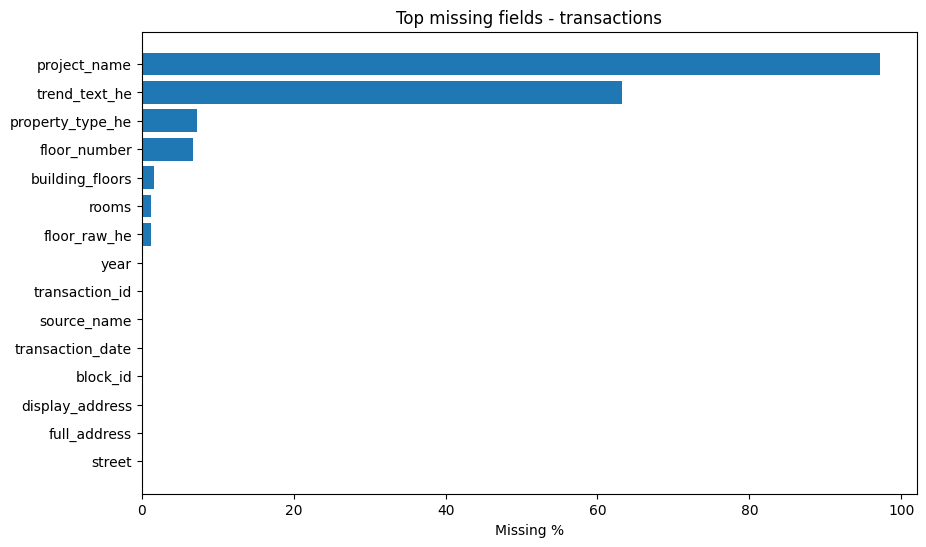

In [ ]:
plt.figure(figsize=(10, 6))
missing_top = missing_report(transactions).head(15)
plt.barh(missing_top["column"], missing_top["missing_pct"])
plt.gca().invert_yaxis()
plt.xlabel("Missing %")
plt.title("Top missing fields - transactions")
plt.show()

## 12. Duplicate detection

In the given data samples, there are no duplications since MongoDB handled deduplication at query time.

## 13. Domain validation

Now, we are going to define valid ranges and business rules.

Examples:
- price must be positive
- rooms must be positive
- quarter must be between 1 and 4
- coordinates must be valid
- building year should be plausible

In [ ]:
validation_report = {
    "price_le_0": int((transactions["price"] <= 0).fillna(False).sum()),
    "rooms_le_0": int((transactions["rooms"] <= 0).fillna(False).sum()),
    "invalid_building_year": int(((transactions["building_year"] < 1800) | (transactions["building_year"] > pd.Timestamp.today().year)).fillna(False).sum()),
    "invalid_floor_number": int((transactions["floor_number"] < 0).fillna(False).sum()),
    "invalid_longitude": int(((transactions["longitude"] < -180) | (transactions["longitude"] > 180)).fillna(False).sum()),
    "invalid_latitude": int(((transactions["latitude"] < -90) | (transactions["latitude"] > 90)).fillna(False).sum()),
    "cbs_invalid_quarter": int(((market_index["quarter"] < 1) | (market_index["quarter"] > 4)).fillna(False).sum()),
}

pd.DataFrame(
    [{"rule": k, "failed_records": v} for k, v in validation_report.items()]
)

,rule,failed_records
0,price_le_0,0
1,rooms_le_0,0
2,invalid_building_year,0
3,invalid_floor_number,0
4,invalid_longitude,0
5,invalid_latitude,0
6,cbs_invalid_quarter,0


## 14. Transaction-level exploratory analysis

At this stage we focus on:
- price distribution
- transaction volume over time
- room counts
- city-level summaries
- floor and building characteristics

In [ ]:
transactions[["price", "rooms", "floor_number", "building_year", "building_floors"]].describe()

,price,rooms,floor_number,building_year,building_floors
count,2.500000e+02,247.000000,233.000000,250.000000,246.000000
mean,2.625028e+06,3.716599,6.639485,1997.604000,14.296748
std,6.567156e+06,0.813159,5.107346,20.164962,9.466878
min,1.220000e+05,2.000000,1.000000,1970.000000,1.000000
25%,8.237500e+05,3.000000,3.000000,1970.000000,4.000000
50%,2.200000e+06,4.000000,4.000000,2009.000000,12.000000
75%,2.680000e+06,4.000000,10.000000,2013.000000,27.000000
max,7.144000e+07,7.000000,20.000000,2020.000000,27.000000


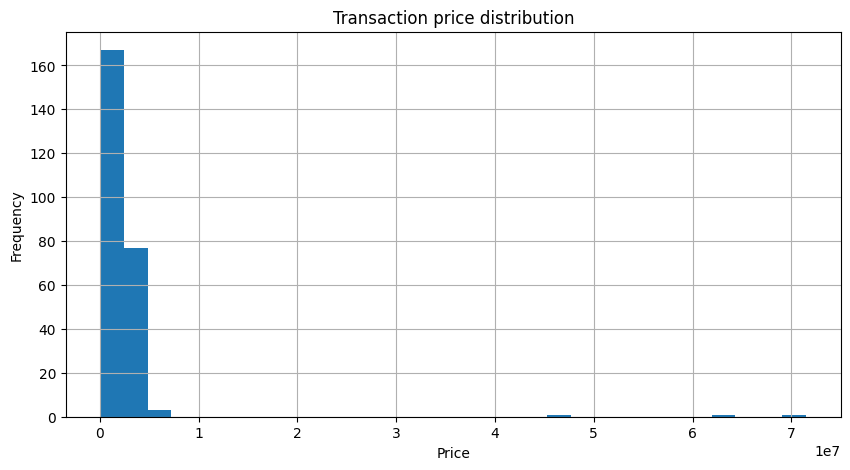

In [ ]:
plt.figure(figsize=(10, 5))
transactions["price"].dropna().hist(bins=30)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Transaction price distribution")
plt.show()

In [ ]:
monthly_tx = (
    transactions.dropna(subset=["transaction_date"])
    .assign(tx_month=lambda d: d["transaction_date"].dt.to_period("M").astype(str))
    .groupby("tx_month")
    .size()
    .reset_index(name="transactions")
)

fig = px.line(monthly_tx, x="tx_month", y="transactions", title="Transactions over time")
fig.show()

In [ ]:
city_summary = (
    transactions.groupby("city", dropna=False)
    .agg(
        n_transactions=("transaction_id", "count"),
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        avg_rooms=("rooms", "mean"),
    )
    .sort_values("n_transactions", ascending=False)
    .reset_index()
)

city_summary.head(20)

,city,n_transactions,avg_price,median_price,avg_rooms
0,רחובות,250,2625028.0,2200000.0,3.716599


In [ ]:
fig = px.bar(
    city_summary.head(15),
    x="city",
    y="avg_price",
    title="Average price by city",
)
fig.show()

## 15. CBS quarterly market trend exploration

The CBS dataset can be used to understand macro housing trends over time.

Key questions:
- how does the housing index change over time?
- how volatile is quarterly change?
- what does annual change look like?

In [ ]:
market_index = market_index.sort_values(["year", "quarter"]).copy()
market_index["period_label"] = (
    market_index["year"].astype("Int64").astype(str)
    + "-Q"
    + market_index["quarter"].astype("Int64").astype(str)
)

market_index.head()

,indicator_id,source_name,indicator_type,series_code,series_name_he,period_type,year,quarter,period_label_he,percent_change_period,percent_change_annual,index_value,base_description_he,ingested_at,period_label
35,40010_1983_Q4,cbs_housing,housing_price_index,40010,מחירי דירות,quarter,1983,4.0,אוקטובר-דצמבר,47.2,NaN,2156.1,1980 ממוצע,2026-03-12 01:30:42.627000+00:00,1983-Q4
81,140235_1983_Q<NA>,cbs_housing,housing_price_index,140235,שכר דירה - בדירות עם זכאות לדמי מפתח,month,1983,NaN,NaN,2.0,NaN,1131.7,1980 ממוצע,2026-03-12 01:24:56.440000+00:00,1983-Q<NA>
82,140235_1983_Q<NA>,cbs_housing,housing_price_index,140235,שכר דירה - בדירות עם זכאות לדמי מפתח,month,1983,NaN,NaN,2.5,NaN,999.7,1980 ממוצע,2026-03-12 01:24:56.440000+00:00,1983-Q<NA>
102,140235_1983_Q<NA>,cbs_housing,housing_price_index,140235,שכר דירה - בדירות עם זכאות לדמי מפתח,month,1983,NaN,NaN,2.9,NaN,959.1,1980 ממוצע,2026-03-12 01:24:56.440000+00:00,1983-Q<NA>
145,140235_1983_Q<NA>,cbs_housing,housing_price_index,140235,שכר דירה - בדירות עם זכאות לדמי מפתח,month,1983,NaN,NaN,1.6,NaN,1150.1,1980 ממוצע,2026-03-12 01:24:56.440000+00:00,1983-Q<NA>


In [ ]:
fig = px.line(
    market_index,
    x="period_label",
    y="index_value",
    title="CBS housing price index over time"
)
fig.update_xaxes(type="category")
fig.show()

In [ ]:
fig = px.line(
    market_index,
    x="period_label",
    y="percent_change_annual",
    title="Annual percent change in housing prices"
)
fig.update_xaxes(type="category")
fig.show()

## 16. Enrich transactions with CBS quarter-level indicators

Because CBS data is quarterly and transaction data is property-level, the correct first integration method is:
- derive year and quarter from transaction date
- join on `(year, quarter)`

This is an EDL-friendly enrichment step because it preserves grain:
- transaction remains transaction-level
- CBS becomes contextual market signal

In [ ]:
transactions_enriched = transactions.merge(
    market_index[
        ["year", "quarter", "series_code", "series_name_he", "index_value", "percent_change_period", "percent_change_annual"]
    ],
    on=["year", "quarter"],
    how="left"
)

transactions_enriched.head()

,transaction_id,source_name,transaction_date,year,month,quarter,city,street,full_address,display_address,...,trend_text_he,longitude,latitude,content_hash,ingested_at,series_code,series_name_he,index_value,percent_change_period,percent_change_annual
0,10082725464,odata_il_nadlan,2020-01-21,2020,1,1,רחובות,כרמל,"כרמל 7, רחובות",כרמל 7,...,None,34.822027,31.906504,54e496d9490e45c9d358916464813d86bd64067e2c96f7...,2026-03-11 21:10:42.445000+00:00,NaN,NaN,NaN,NaN,NaN
1,10082413572,odata_il_nadlan,2020-01-21,2020,1,1,רחובות,כרמל,"כרמל 4, רחובות",כרמל 4,...,125% ב 12.7 שנים,34.821559,31.905816,1a1fef7022f9e47a1b71105e299915aa50541aeec2ecb5...,2026-03-11 21:10:42.445000+00:00,NaN,NaN,NaN,NaN,NaN
2,10099719840,odata_il_nadlan,2020-08-21,2020,8,3,רחובות,כרמל,"כרמל 1, רחובות",כרמל 1,...,88% ב 12.8 שנים,34.820953,31.906285,b8f917e82bf9f0526636d08e3a860926388226f5aec568...,2026-03-11 21:10:42.445000+00:00,NaN,NaN,NaN,NaN,NaN
3,10169466720,odata_il_nadlan,2021-02-16,2021,2,1,רחובות,כרמל,"כרמל 7, רחובות",כרמל 7,...,None,34.822027,31.906504,69613c62dffc2232dc5766b3c5f3ca2e65fb54776e2dfb...,2026-03-11 21:10:42.445000+00:00,NaN,NaN,NaN,NaN,NaN
4,10178027580,odata_il_nadlan,2021-04-29,2021,4,2,רחובות,כרמל,"כרמל 19, רחובות",כרמל 19,...,None,34.822620,31.908039,610e3341145f5d6783ba0538c0477bd5dd56cda4c76b4b...,2026-03-11 21:10:42.445000+00:00,NaN,NaN,NaN,NaN,NaN


In [ ]:
transactions_enriched[
    ["transaction_id", "transaction_date", "price", "year", "quarter", "index_value", "percent_change_annual"]
].head(10)

,transaction_id,transaction_date,price,year,quarter,index_value,percent_change_annual
0,10082725464,2020-01-21,2050000,2020,1,NaN,NaN
1,10082413572,2020-01-21,2040000,2020,1,NaN,NaN
2,10099719840,2020-08-21,2200000,2020,3,NaN,NaN
3,10169466720,2021-02-16,2165000,2021,1,NaN,NaN
4,10178027580,2021-04-29,2225000,2021,2,NaN,NaN
5,10179086400,2021-05-10,2000000,2021,2,NaN,NaN
6,10187975532,2021-07-29,2350000,2021,3,NaN,NaN
7,10265908128,2022-05-29,2680000,2022,2,NaN,NaN
8,10348771020,2023-07-04,71440000,2023,3,NaN,NaN
9,10350686388,2023-08-08,408000,2023,3,NaN,NaN


## 17. Data quality notes and limitations

At this stage, the initial dataset has several limitations:

1. The transaction sample currently lacks some important real-estate predictors, especially apartment area in square meters.
2. Hebrew categorical fields still need fuller normalization dictionaries.
3. Deal codes such as `DEALNATURE` are still source-specific and should be documented through lookup analysis.
4. CBS data is macro-level and not region-specific in the current sample, so it provides temporal context but not local neighborhood context.
5. The current notebook focuses on initial EDL and preprocessing, not yet on modeling.

These limitations are acceptable for the first project milestone because the main goal here is:
- understand the data,
- document preprocessing,
- produce a canonical analytical table,
- and build a reproducible exploration workflow.

## 18. Export normalized datasets

A good reproducibility practice is to persist the cleaned outputs used later by:
- feature engineering
- model training
- dashboard summaries

In [ ]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

transactions.to_csv(OUTPUT_DIR / "clean_transactions.csv", index=False, encoding="utf-8-sig")
market_index.to_csv(OUTPUT_DIR / "clean_market_index.csv", index=False, encoding="utf-8-sig")
transactions_enriched.to_csv(OUTPUT_DIR / "transactions_enriched.csv", index=False, encoding="utf-8-sig")

print("Saved cleaned outputs to:", OUTPUT_DIR.resolve())

Saved cleaned outputs to: /content/outputs


## 19. Summary

In this notebook we performed the first complete EDL and exploratory workflow for the project:

- loaded raw transaction and CBS records
- inspected the ingestion envelope and source payloads
- profiled schema, missingness, and cardinality
- normalized types and selected fields
- converted Hebrew floor labels into numeric values
- created canonical analytical tables
- validated basic business rules
- visualized price distributions and market index trends
- enriched transaction records with quarter-level CBS indicators
